# 2026-05-15 fixed_N 개별 데이터셋 EDA 개요

`preprocess/data/processed/fixed_N{n}/{variant}` 구조로 생성된 개별 연도 기준 라벨 데이터셋을 비교합니다. 기존 H 방식(horizon window)이 아니라 상폐연도 기준 정확히 N년 전 데이터를 label=1로 둔 fixed labeling 결과를 대상으로 합니다.


## 1. 설정 & 데이터 로드

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "preprocess").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

DATA_ROOT = PROJECT_ROOT / "preprocess" / "data" / "processed"
N_VALUES = [1, 2, 3]
VARIANTS = ["baseline", "exp-A", "exp-B", "exp-C"]
SPLITS = ["train", "valid", "test"]
KEY_COLS = ["stock_code", "year", "quarter"]
TARGET_COLUMN = "label"

from matplotlib import font_manager, rcParams

sns.set_theme(style="whitegrid")
available_fonts = {font.name for font in font_manager.fontManager.ttflist}
for font_name in ["AppleGothic", "NanumGothic", "Malgun Gothic"]:
    if font_name in available_fonts:
        rcParams["font.family"] = font_name
        break
rcParams["axes.unicode_minus"] = False
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)


In [2]:
def dataset_dir(n_years, variant):
    return DATA_ROOT / f"fixed_N{n_years}" / variant


def load_meta(n_years, variant):
    path = dataset_dir(n_years, variant) / "meta.json"
    if not path.exists():
        return None
    with open(path, encoding="utf-8") as f:
        return json.load(f)


def load_split(n_years, variant, split):
    path = dataset_dir(n_years, variant) / f"{split}.csv"
    if not path.exists():
        return None
    return pd.read_csv(path, dtype={"stock_code": str})


def load_dataset(n_years, variant):
    return {split: load_split(n_years, variant, split) for split in SPLITS}

available = []
for n in N_VALUES:
    for variant in VARIANTS:
        if dataset_dir(n, variant).exists():
            available.append((n, variant))

available


[(1, 'baseline'),
 (1, 'exp-A'),
 (1, 'exp-B'),
 (1, 'exp-C'),
 (2, 'baseline'),
 (2, 'exp-A'),
 (2, 'exp-B'),
 (2, 'exp-C'),
 (3, 'baseline'),
 (3, 'exp-A'),
 (3, 'exp-B'),
 (3, 'exp-C')]

## 2. 메타 비교

split 크기, 양성 라벨 수, 불균형 비율, 전처리 variant 설정을 먼저 확인합니다.


In [3]:
meta_rows = []
for n, variant in available:
    meta = load_meta(n, variant)
    if meta is None:
        continue
    row = {
        "N": n,
        "dataset": f"fixed_N{n}",
        "variant": variant,
        "winsorize": meta.get("winsorize"),
        "robust_scale": meta.get("robust_scale"),
        "train_rows": meta.get("train_rows"),
        "valid_rows": meta.get("valid_rows"),
        "test_rows": meta.get("test_rows"),
        "train_pos": meta.get("train_pos"),
        "valid_pos": meta.get("valid_pos"),
        "test_pos": meta.get("test_pos"),
        "unique_delisted_pos": meta.get("unique_delisted_pos"),
        "imbalance_ratio": meta.get("imbalance_ratio"),
        "labeling_rule": meta.get("labeling_rule"),
    }
    for split in SPLITS:
        rows = row.get(f"{split}_rows") or 0
        pos = row.get(f"{split}_pos") or 0
        row[f"{split}_pos_rate_pct"] = pos / rows * 100 if rows else 0
    meta_rows.append(row)

meta_df = pd.DataFrame(meta_rows).sort_values(["N", "variant"]).reset_index(drop=True)
meta_df


,N,dataset,variant,winsorize,robust_scale,train_rows,valid_rows,test_rows,train_pos,valid_pos,test_pos,unique_delisted_pos,imbalance_ratio,labeling_rule,train_pos_rate_pct,valid_pos_rate_pct,test_pos_rate_pct
0,1,fixed_N1,baseline,False,False,35493,5050,5311,283,39,56,106,124.4,상폐연도 기준 정확히 1년 전 연도의 전 분기(Q1/H1/Q3/ANNUAL) lab...,0.797340,0.772277,1.054415
1,1,fixed_N1,exp-A,True,False,35493,5050,5311,283,39,56,106,124.4,상폐연도 기준 정확히 1년 전 연도의 전 분기(Q1/H1/Q3/ANNUAL) lab...,0.797340,0.772277,1.054415
2,1,fixed_N1,exp-B,False,True,35493,5050,5311,283,39,56,106,124.4,상폐연도 기준 정확히 1년 전 연도의 전 분기(Q1/H1/Q3/ANNUAL) lab...,0.797340,0.772277,1.054415
3,1,fixed_N1,exp-C,True,True,35493,5050,5311,283,39,56,106,124.4,상폐연도 기준 정확히 1년 전 연도의 전 분기(Q1/H1/Q3/ANNUAL) lab...,0.797340,0.772277,1.054415
4,2,fixed_N2,baseline,False,False,35493,5050,5311,293,60,24,99,120.1,상폐연도 기준 정확히 2년 전 연도의 전 분기(Q1/H1/Q3/ANNUAL) lab...,0.825515,1.188119,0.451892
5,2,fixed_N2,exp-A,True,False,35493,5050,5311,293,60,24,99,120.1,상폐연도 기준 정확히 2년 전 연도의 전 분기(Q1/H1/Q3/ANNUAL) lab...,0.825515,1.188119,0.451892
6,2,fixed_N2,exp-B,False,True,35493,5050,5311,293,60,24,99,120.1,상폐연도 기준 정확히 2년 전 연도의 전 분기(Q1/H1/Q3/ANNUAL) lab...,0.825515,1.188119,0.451892
7,2,fixed_N2,exp-C,True,True,35493,5050,5311,293,60,24,99,120.1,상폐연도 기준 정확히 2년 전 연도의 전 분기(Q1/H1/Q3/ANNUAL) lab...,0.825515,1.188119,0.451892
8,3,fixed_N3,baseline,False,False,35493,5050,5311,316,24,0,94,111.3,상폐연도 기준 정확히 3년 전 연도의 전 분기(Q1/H1/Q3/ANNUAL) lab...,0.890316,0.475248,0.000000
9,3,fixed_N3,exp-A,True,False,35493,5050,5311,316,24,0,94,111.3,상폐연도 기준 정확히 3년 전 연도의 전 분기(Q1/H1/Q3/ANNUAL) lab...,0.890316,0.475248,0.000000


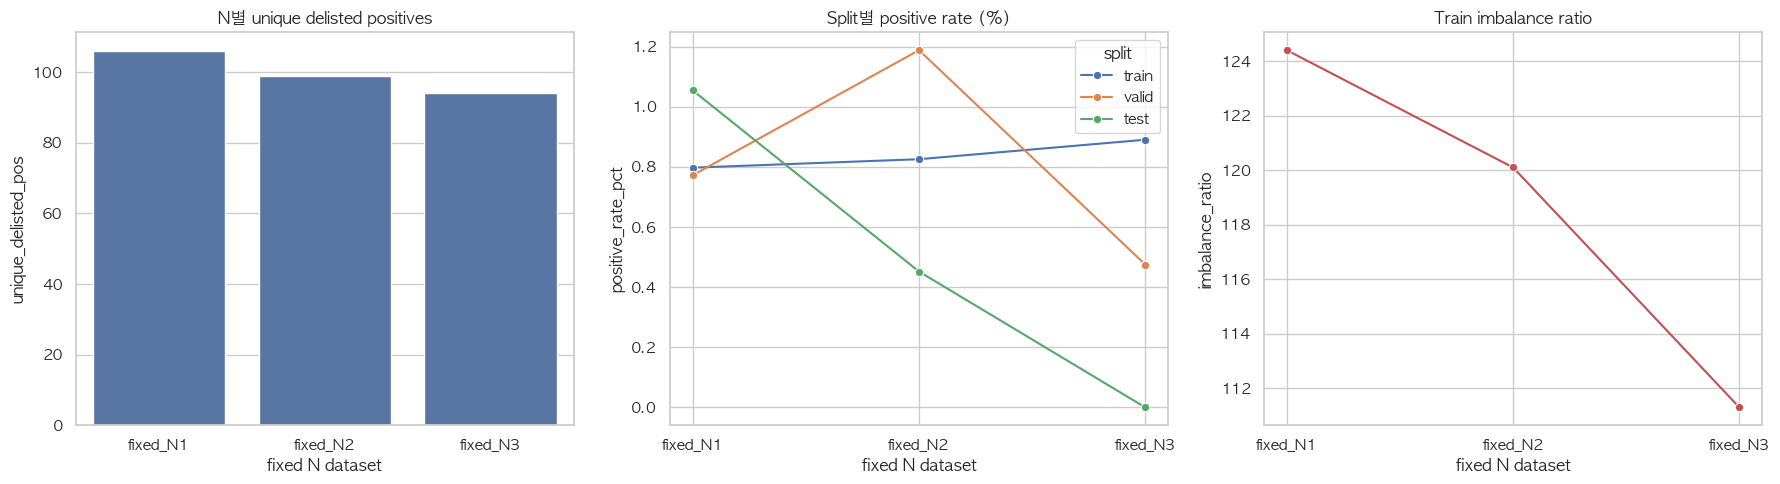

In [7]:
label_meta_df = meta_df[meta_df["variant"] == "baseline"].copy()
label_meta_df["N_label"] = label_meta_df["N"].map(lambda n: f"fixed_N{n}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
plot_df = label_meta_df.melt(
    id_vars=["N", "N_label"],
    value_vars=["train_pos_rate_pct", "valid_pos_rate_pct", "test_pos_rate_pct"],
    var_name="split",
    value_name="positive_rate_pct",
)
plot_df["split"] = plot_df["split"].str.replace("_pos_rate_pct", "", regex=False)

sns.barplot(data=label_meta_df, x="N_label", y="unique_delisted_pos", ax=axes[0], color="#4c72b0")
axes[0].set_title("N별 unique delisted positives")
axes[0].set_xlabel("fixed N dataset")
axes[0].set_ylabel("unique_delisted_pos")

sns.lineplot(data=plot_df, x="N_label", y="positive_rate_pct", hue="split", marker="o", ax=axes[1])
axes[1].set_title("Split별 positive rate (%)")
axes[1].set_xlabel("fixed N dataset")
axes[1].set_ylabel("positive_rate_pct")

sns.lineplot(data=label_meta_df, x="N_label", y="imbalance_ratio", marker="o", ax=axes[2], color="#c44e52")
axes[2].set_title("Train imbalance ratio")
axes[2].set_xlabel("fixed N dataset")
axes[2].set_ylabel("imbalance_ratio")

for ax in axes:
    ax.tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()


## 3. 데이터 품질 비교

각 fixed_N/variant/split의 결측률, 중복 키, 컬럼 수를 비교합니다.


In [8]:
quality_rows = []
for n, variant in available:
    for split in SPLITS:
        df = load_split(n, variant, split)
        if df is None:
            continue
        numeric_cols = df.select_dtypes(include="number").columns.tolist()
        feature_cols = [c for c in numeric_cols if c != TARGET_COLUMN]
        duplicate_keys = df.duplicated(KEY_COLS).sum() if set(KEY_COLS).issubset(df.columns) else None
        quality_rows.append({
            "N": n,
            "dataset": f"fixed_N{n}",
            "variant": variant,
            "split": split,
            "rows": len(df),
            "columns": len(df.columns),
            "feature_columns": len(feature_cols),
            "positive": int(df[TARGET_COLUMN].sum()) if TARGET_COLUMN in df.columns else None,
            "positive_rate_pct": df[TARGET_COLUMN].mean() * 100 if TARGET_COLUMN in df.columns else None,
            "avg_feature_missing_pct": df[feature_cols].isna().mean().mean() * 100 if feature_cols else 0,
            "max_feature_missing_pct": df[feature_cols].isna().mean().max() * 100 if feature_cols else 0,
            "duplicate_key_rows": duplicate_keys,
        })

quality_df = pd.DataFrame(quality_rows).sort_values(["N", "variant", "split"]).reset_index(drop=True)
quality_df


,N,dataset,variant,split,rows,columns,feature_columns,positive,positive_rate_pct,avg_feature_missing_pct,max_feature_missing_pct,duplicate_key_rows
0,1,fixed_N1,baseline,test,5311,41,37,56,1.054415,0.0,0.0,0
1,1,fixed_N1,baseline,train,35493,41,37,283,0.797340,0.0,0.0,0
2,1,fixed_N1,baseline,valid,5050,41,37,39,0.772277,0.0,0.0,0
3,1,fixed_N1,exp-A,test,5311,41,37,56,1.054415,0.0,0.0,0
4,1,fixed_N1,exp-A,train,35493,41,37,283,0.797340,0.0,0.0,0
5,1,fixed_N1,exp-A,valid,5050,41,37,39,0.772277,0.0,0.0,0
6,1,fixed_N1,exp-B,test,5311,41,37,56,1.054415,0.0,0.0,0
7,1,fixed_N1,exp-B,train,35493,41,37,283,0.797340,0.0,0.0,0
8,1,fixed_N1,exp-B,valid,5050,41,37,39,0.772277,0.0,0.0,0
9,1,fixed_N1,exp-C,test,5311,41,37,56,1.054415,0.0,0.0,0


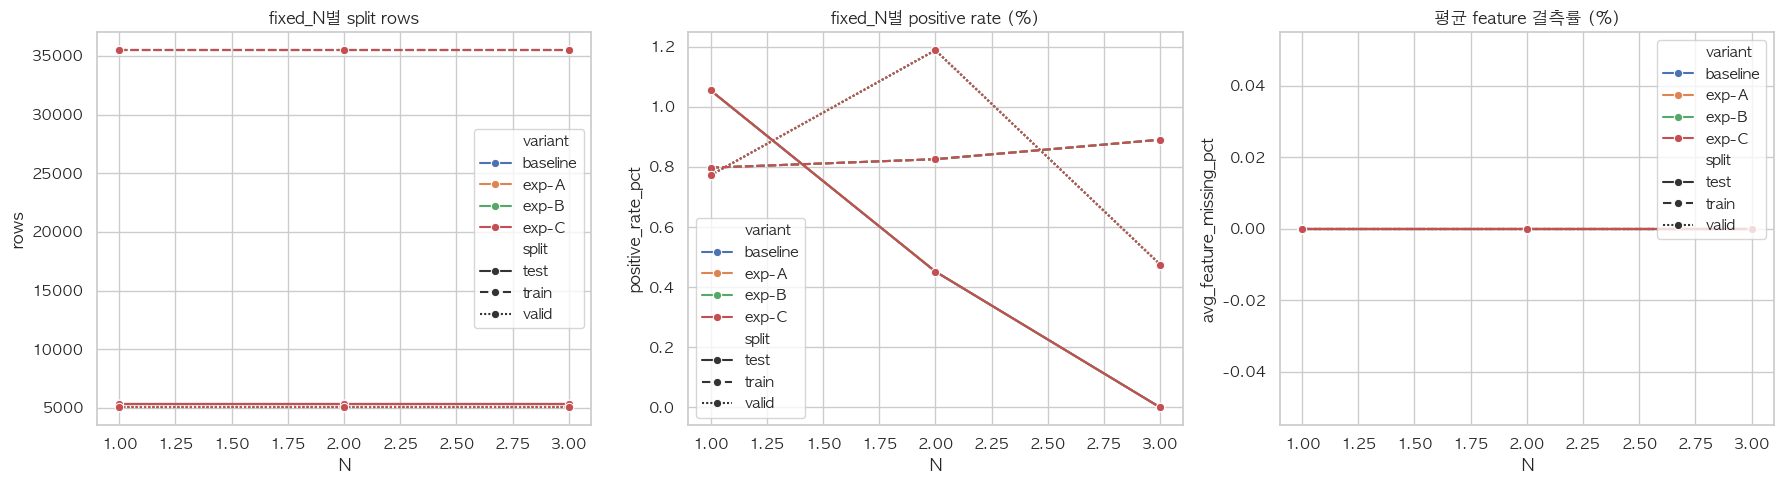

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.lineplot(data=quality_df, x="N", y="rows", hue="variant", style="split", marker="o", ax=axes[0])
axes[0].set_title("fixed_N별 split rows")

sns.lineplot(data=quality_df, x="N", y="positive_rate_pct", hue="variant", style="split", marker="o", ax=axes[1])
axes[1].set_title("fixed_N별 positive rate (%)")

sns.lineplot(data=quality_df, x="N", y="avg_feature_missing_pct", hue="variant", style="split", marker="o", ax=axes[2])
axes[2].set_title("평균 feature 결측률 (%)")

plt.tight_layout()
plt.show()


## 4. Variant 전처리 효과 확인

baseline 대비 winsorize/robust scale 적용 후 수치형 피처의 분위수와 스케일이 어떻게 달라졌는지 빠르게 비교합니다.


In [10]:
SELECTED_N = 1
SELECTED_SPLIT = "train"
COMPARE_FEATURES = [
    "부채비율", "유동비율", "자기자본비율", "매출액순이익률",
    "자기자본순이익률", "총자본영업이익률", "총자본회전율", "차입금의존도",
]

variant_stat_rows = []
for variant in VARIANTS:
    df = load_split(SELECTED_N, variant, SELECTED_SPLIT)
    if df is None:
        continue
    for col in COMPARE_FEATURES:
        if col not in df.columns:
            continue
        s = pd.to_numeric(df[col], errors="coerce")
        variant_stat_rows.append({
            "N": SELECTED_N,
            "variant": variant,
            "feature": col,
            "missing_pct": s.isna().mean() * 100,
            "mean": s.mean(),
            "std": s.std(),
            "p01": s.quantile(0.01),
            "p50": s.quantile(0.50),
            "p99": s.quantile(0.99),
            "min": s.min(),
            "max": s.max(),
        })

variant_stats = pd.DataFrame(variant_stat_rows)
variant_stats


,N,variant,feature,missing_pct,mean,std,p01,p50,p99,min,max
0,1,baseline,부채비율,0.0,107.594341,148.541401,4.579811,71.669925,633.746355,0.000000,2000.000000
1,1,baseline,유동비율,0.0,338.904068,389.763823,31.392172,195.499323,2000.000000,0.000000,2000.000000
2,1,baseline,자기자본비율,0.0,61.410252,23.065106,11.370418,62.865942,95.967227,-500.000000,100.000000
3,1,baseline,매출액순이익률,0.0,-14.391732,75.423769,-500.000000,2.169803,65.372664,-500.000000,100.000000
4,1,baseline,자기자본순이익률,0.0,-3.047208,31.110040,-99.875187,0.930993,28.221461,-500.000000,100.000000
5,1,baseline,총자본영업이익률,0.0,0.393513,8.344676,-23.582846,0.705609,17.491786,-500.000000,64.508575
6,1,baseline,총자본회전율,0.0,0.340534,0.379532,0.007486,0.207472,1.765610,0.000000,5.546385
7,1,baseline,차입금의존도,0.0,9.941669,12.612331,0.000000,4.366868,48.569436,0.000000,100.000000
8,1,exp-A,부채비율,0.0,107.594341,148.541401,4.579811,71.669925,633.746355,0.000000,2000.000000
9,1,exp-A,유동비율,0.0,338.904068,389.763823,31.392172,195.499323,2000.000000,0.000000,2000.000000


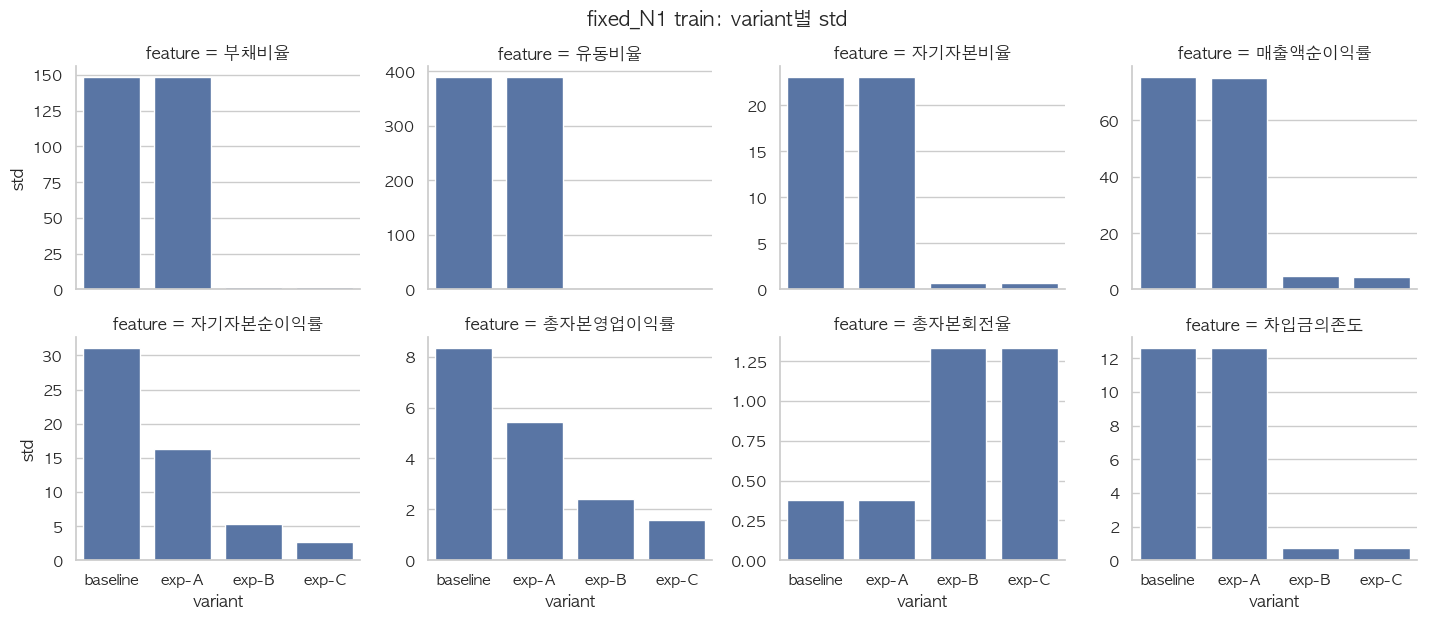

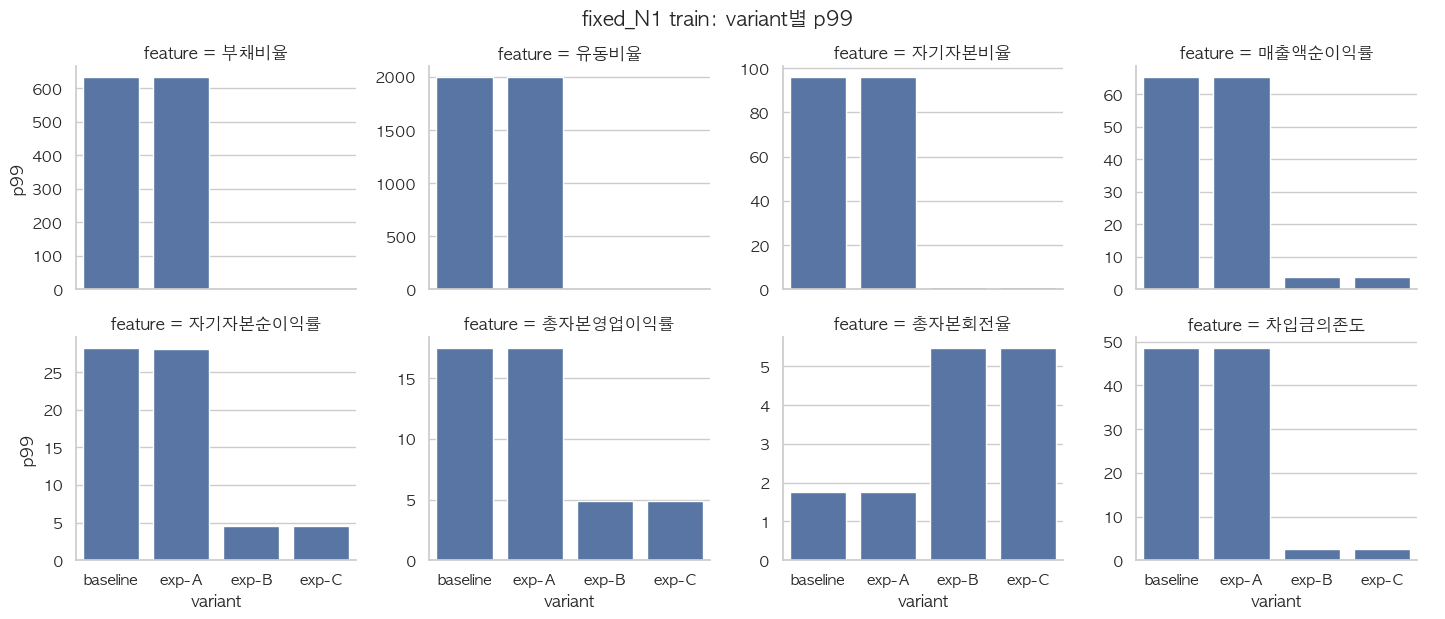

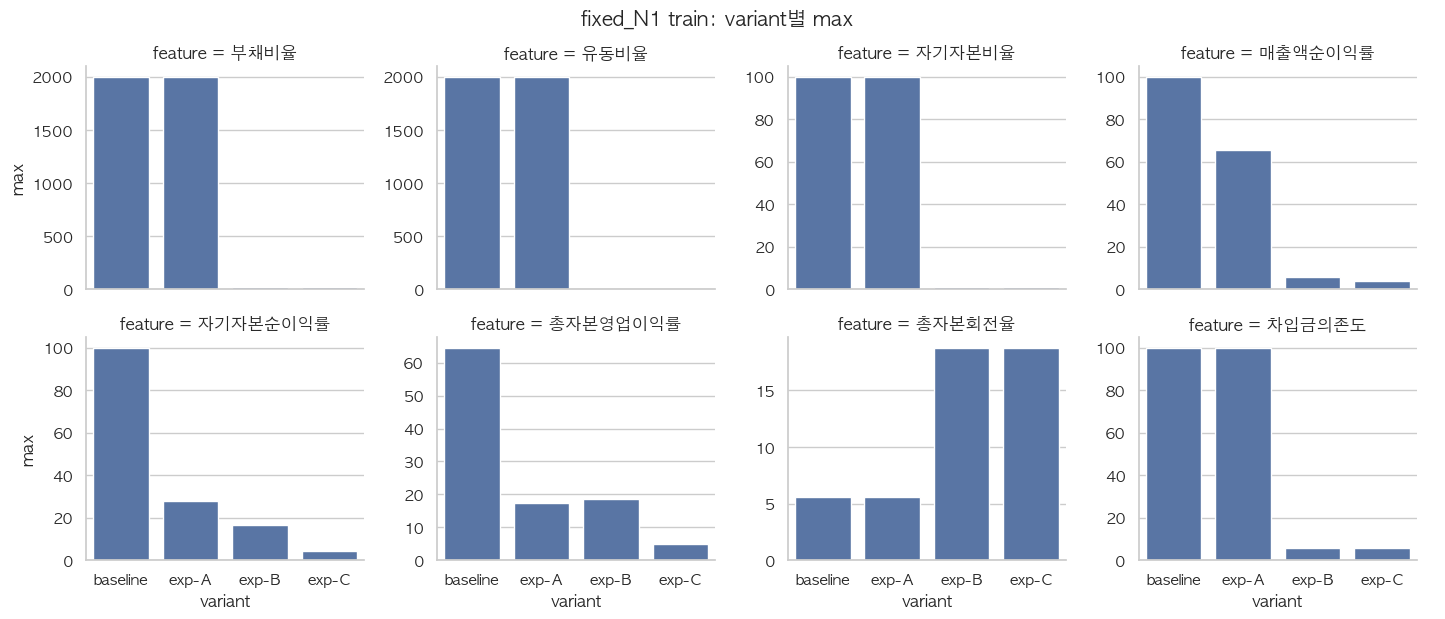

In [11]:
if not variant_stats.empty:
    for metric in ["std", "p99", "max"]:
        g = sns.catplot(
            data=variant_stats,
            x="variant",
            y=metric,
            col="feature",
            col_wrap=4,
            kind="bar",
            sharey=False,
            height=3,
            aspect=1.2,
        )
        g.fig.suptitle(f"fixed_N{SELECTED_N} {SELECTED_SPLIT}: variant별 {metric}", y=1.03)
        plt.show()


## 5. fixed_N별 label scatter 비교

baseline train split 기준으로 주요 피처 조합의 label 분리 가능성을 `fixed_N1~N3`에 걸쳐 비교합니다. 양성 label은 전부 유지하고 음성 label만 샘플링해 시각화 비용을 낮춥니다.


In [ ]:
SCATTER_FEATURE_PAIRS = [
    ("부채비율", "매출액순이익률"),
    ("부채비율", "총자본영업이익률"),
    ("차입금의존도", "현금비율"),
]
SCATTER_N_VALUES = [1, 2]  # fixed_N3는 test_pos=0이라 기본 비교에서 제외
SCATTER_VARIANT = "baseline"
SCATTER_SPLIT = "train"
SCATTER_MAX_NEGATIVE = 600


def sample_for_scatter(frame, max_negative=600, random_state=42):
    positive = frame[frame[TARGET_COLUMN] == 1]
    negative = frame[frame[TARGET_COLUMN] == 0]
    if len(negative) > max_negative:
        negative = negative.sample(max_negative, random_state=random_state)
    return pd.concat([positive, negative], ignore_index=True)


def clipped_for_plot(frame, columns, q_low=0.01, q_high=0.99):
    out = frame.copy()
    for col in columns:
        if col not in out.columns:
            continue
        lower = out[col].quantile(q_low)
        upper = out[col].quantile(q_high)
        out[col] = out[col].clip(lower, upper)
    return out

scatter_frames = []
for n in SCATTER_N_VALUES:
    split_df = load_split(n, SCATTER_VARIANT, SCATTER_SPLIT)
    if split_df is None:
        continue
    needed_cols = [TARGET_COLUMN, "stock_code", "year", "quarter"]
    feature_cols = sorted({c for pair in SCATTER_FEATURE_PAIRS for c in pair})
    keep_cols = [c for c in needed_cols + feature_cols if c in split_df.columns]
    sampled = sample_for_scatter(split_df[keep_cols], max_negative=SCATTER_MAX_NEGATIVE)
    sampled["N"] = f"fixed_N{n}"
    scatter_frames.append(sampled)

scatter_df = pd.concat(scatter_frames, ignore_index=True)
plot_cols = sorted({c for pair in SCATTER_FEATURE_PAIRS for c in pair if c in scatter_df.columns})
scatter_df = clipped_for_plot(scatter_df, plot_cols)
scatter_df[TARGET_COLUMN] = scatter_df[TARGET_COLUMN].map({0: "healthy", 1: "delisted"})
scatter_df.shape


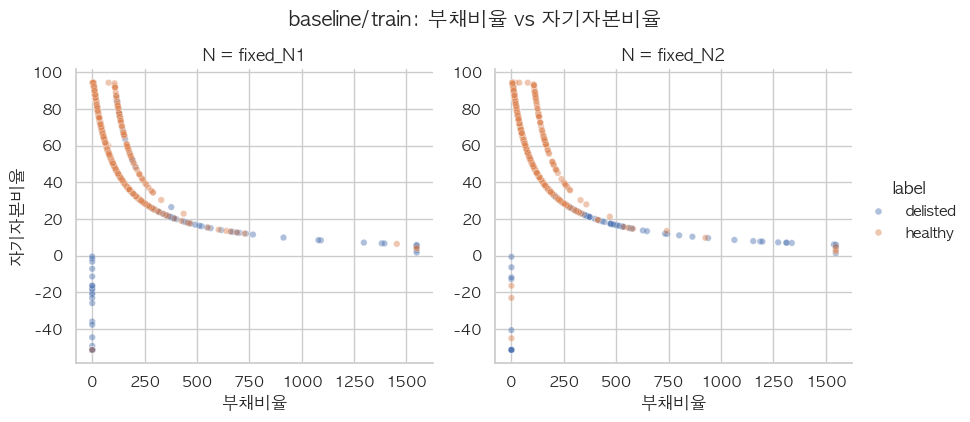

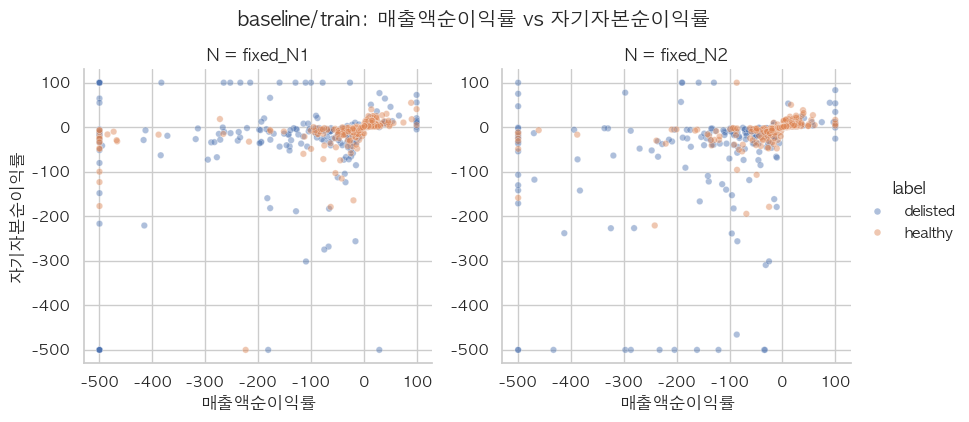

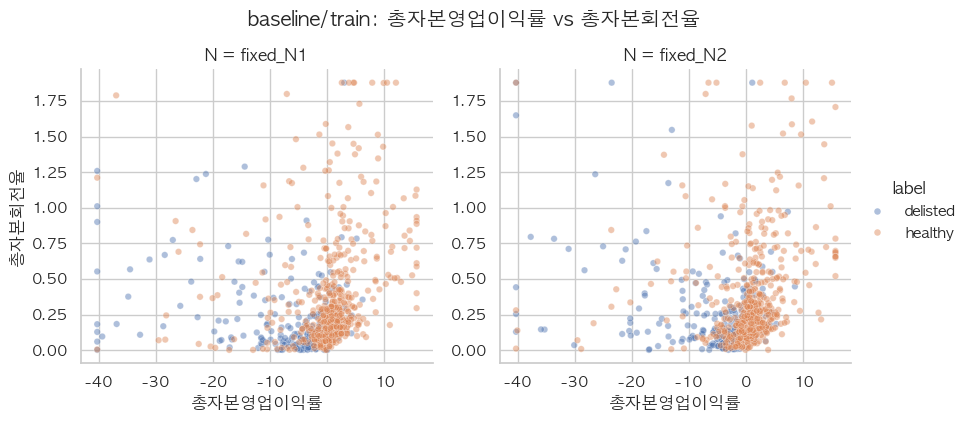

In [14]:
for x_col, y_col in SCATTER_FEATURE_PAIRS:
    if x_col not in scatter_df.columns or y_col not in scatter_df.columns:
        print(f"[SKIP] {x_col} x {y_col}")
        continue
    g = sns.relplot(
        data=scatter_df,
        x=x_col,
        y=y_col,
        hue=TARGET_COLUMN,
        col="N",
        kind="scatter",
        alpha=0.45,
        s=22,
        height=4,
        aspect=1.1,
        facet_kws={"sharex": False, "sharey": False},
    )
    g.fig.suptitle(f"{SCATTER_VARIANT}/{SCATTER_SPLIT}: {x_col} vs {y_col}", y=1.05)
    plt.show()


## 5. Split 누수/중복 점검

동일 `(stock_code, year, quarter)` 키가 train/valid/test 사이에 겹치는지 확인합니다.


In [16]:
leak_rows = []
for n, variant in available:
    split_map = load_dataset(n, variant)
    if any(split_map[s] is None for s in SPLITS):
        continue
    key_sets = {
        split: set(map(tuple, split_map[split][KEY_COLS].astype(str).to_numpy()))
        for split in SPLITS
    }
    for left, right in [("train", "valid"), ("train", "test"), ("valid", "test")]:
        overlap = key_sets[left] & key_sets[right]
        leak_rows.append({
            "N": n,
            "variant": variant,
            "pair": f"{left}-{right}",
            "overlap_keys": len(overlap),
        })

leak_df = pd.DataFrame(leak_rows)
leak_df.pivot_table(index=["N", "variant"], columns="pair", values="overlap_keys", fill_value=0)


pair        train-test  train-valid  valid-test
N variant                                      
1 baseline         0.0          0.0         0.0
  exp-A            0.0          0.0         0.0
  exp-B            0.0          0.0         0.0
  exp-C            0.0          0.0         0.0
2 baseline         0.0          0.0         0.0
  exp-A            0.0          0.0         0.0
  exp-B            0.0          0.0         0.0
  exp-C            0.0          0.0         0.0
3 baseline         0.0          0.0         0.0
  exp-A            0.0          0.0         0.0
  exp-B            0.0          0.0         0.0
  exp-C            0.0          0.0         0.0

## 6. Label 구성 차이

fixed_N 간 양성 기업/분기 구성이 얼마나 겹치는지 확인합니다. 동일 회사가 N별로 이동해 들어가는 구조인지, 특정 N에서 test 양성이 사라지는지 확인하는 용도입니다.


In [17]:
positive_key_rows = []
for n, variant in available:
    if variant != "baseline":
        continue
    for split in SPLITS:
        df = load_split(n, variant, split)
        if df is None or TARGET_COLUMN not in df.columns:
            continue
        pos = df[df[TARGET_COLUMN] == 1].copy()
        positive_key_rows.append({
            "N": n,
            "split": split,
            "positive_rows": len(pos),
            "positive_companies": pos["stock_code"].nunique() if "stock_code" in pos.columns else None,
            "years": sorted(pos["year"].dropna().unique().tolist()) if "year" in pos.columns else [],
            "quarters": sorted(pos["quarter"].dropna().unique().tolist()) if "quarter" in pos.columns else [],
        })

positive_key_df = pd.DataFrame(positive_key_rows)
positive_key_df


,N,split,positive_rows,positive_companies,years,quarters
0,1,train,283,81,"[2015, 2016, 2017, 2018, 2019, 2020, 2021, 202...","[ANNUAL, H1, Q1, Q3]"
1,1,valid,39,10,[2023],"[ANNUAL, H1, Q1, Q3]"
2,1,test,56,15,[2024],"[ANNUAL, H1, Q1, Q3]"
3,2,train,293,78,"[2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022]","[ANNUAL, H1, Q1, Q3]"
4,2,valid,60,15,[2023],"[ANNUAL, H1, Q1, Q3]"
5,2,test,24,6,[2024],"[ANNUAL, H1, Q1, Q3]"
6,3,train,316,88,"[2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022]","[ANNUAL, H1, Q1, Q3]"
7,3,valid,24,6,[2023],"[ANNUAL, H1, Q1, Q3]"
8,3,test,0,0,[],[]


In [18]:
baseline_pos_sets = {}
for n in N_VALUES:
    df = load_split(n, "baseline", "train")
    if df is not None:
        pos = df[df[TARGET_COLUMN] == 1]
        baseline_pos_sets[n] = set(pos["stock_code"].astype(str))

overlap_rows = []
for left in N_VALUES:
    for right in N_VALUES:
        left_set = baseline_pos_sets.get(left, set())
        right_set = baseline_pos_sets.get(right, set())
        union = left_set | right_set
        overlap_rows.append({
            "left_N": left,
            "right_N": right,
            "intersection_companies": len(left_set & right_set),
            "jaccard": len(left_set & right_set) / len(union) if union else 0,
        })

pd.DataFrame(overlap_rows).pivot(index="left_N", columns="right_N", values="jaccard")


right_N,1,2,3
left_N,,,
1,1.000000,0.747253,0.579439
2,0.747253,1.000000,0.765957
3,0.579439,0.765957,1.000000
